In [1]:
import os
from google.colab import files

if not os.path.exists('/content/kaggle.json'):
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading dataset from Kaggle...")
!kaggle datasets download -d fakhrealam9537/leaf-disease-segmentation-dataset

print("Extracting only the 'data' folder...")
!unzip -q leaf-disease-segmentation-dataset.zip "data/*" -d /content/

if os.path.exists('leaf-disease-segmentation-dataset.zip'):
    os.remove('leaf-disease-segmentation-dataset.zip')
    print("Cleaned up workspace by removing the master zip file.")

print("\nSuccess! The 'data' folder is ready at: /content/data")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/fakhrealam9537/leaf-disease-segmentation-dataset
License(s): CC0-1.0
100% 503M/503M [00:04<00:00, 121MB/s]

Extracting only the 'data' folder...
Cleaned up workspace by removing the master zip file.

Success! The 'data' folder is ready at: /content/data


### Data Augmentation

In [3]:
import os
import cv2
import albumentations as A
from tqdm import tqdm

image_dir = "data/data/images"
mask_dir = "data/data/masks"

aug_image_dir = "data/aug_data/images"
aug_mask_dir = "data/aug_data/masks"

os.makedirs(aug_image_dir, exist_ok= True)
os.makedirs(aug_mask_dir, exist_ok= True)

transform = A.Compose([
    A.HorizontalFlip(p= 0.5), A.VerticalFlip(p= 0.5), A.RandomRotate90(p= 0.5),
    A.ShiftScaleRotate(shift_limit= 0.05, scale_limit= 0.15, rotate_limit= 30, p= 0.8),
    A.RandomBrightnessContrast(brightness_limit= 0.2, contrast_limit= 0.2, p= 0.5),
    A.HueSaturationValue(hue_shift_limit= 10, sat_shift_limit= 15, val_shift_limit= 10, p= 0.5),
    A.GaussNoise(std_range= (0.1, 0.2), p= 0.3), A.GaussianBlur(blur_limit= (3, 5), p= 0.2),A.CLAHE(clip_limit= 4.0, p= 0.3)
])

N_AUG = 7
image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
for image_name in tqdm(image_files):
    img_path = os.path.join(image_dir, image_name)
    base_name = os.path.splitext(image_name)[0]
    mask_path = os.path.join(mask_dir, f"{base_name}.png")
    if not os.path.exists(mask_path):
        mask_path = os.path.join(mask_dir, f"{base_name}.jpg")

    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"Warning: Mask missing for {image_name} (checked paths: {base_name}.png/.jpg). Skipping.")
        continue

    cv2.imwrite(os.path.join(aug_image_dir, image_name), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    out_mask_ext = os.path.splitext(mask_path)[1]
    cv2.imwrite(os.path.join(aug_mask_dir, f"{base_name}{out_mask_ext}"), mask)

    for i in range(N_AUG):
        augmented = transform(image= image, mask= mask)
        aug_image = augmented['image']
        aug_mask = augmented['mask']

        img_output_name = f"{base_name}_aug_{i}.jpg"
        mask_output_name = f"{base_name}_aug_{i}.png"

        cv2.imwrite(os.path.join(aug_image_dir, img_output_name), cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(aug_mask_dir, mask_output_name), aug_mask)

print("Augmentation completed successfully!")

100%|██████████| 588/588 [02:45<00:00,  3.55it/s]

Augmentation completed successfully!


In [4]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

all_images = sorted(os.listdir("data/aug_data/images"))
train_imgs, val_imgs = train_test_split(all_images, test_size= 0.2, random_state= 42)

import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([A.Resize(512, 512), A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5), A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=30, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.5), A.CLAHE(clip_limit=4.0, p=0.3),
    A.GaussNoise(std_range=(0.1, 0.2), p=0.3), A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()
])

val_transform = A.Compose([A.Resize(512, 512), A.Normalize(mean= (0.485, 0.456, 0.406), std= (0.229, 0.224, 0.225)),ToTensorV2()])

class SubsetDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_list, transform= None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        image_name = self.image_list[idx]
        image_path = os.path.join(self.image_dir, image_name)

        base_name = image_name.split("_aug_")[0]
        base_name = os.path.splitext(base_name)[0]

        if "_aug_" in image_name:
            aug_id = image_name.split("_aug_")[1].split(".")[0]
            mask_name = f"{base_name}_aug_{aug_id}.png"
        else:
            mask_name = f"{base_name}.png"

        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        mask = (mask > 0).astype(np.float32)
        if self.transform:
            augmented = self.transform(image= image, mask= mask)

            image = augmented["image"]
            mask = augmented["mask"]

        mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
        return image, mask

train_dataset = SubsetDataset("data/aug_data/images", "data/aug_data/masks", train_imgs, train_transform)
val_dataset = SubsetDataset("data/aug_data/images", "data/aug_data/masks", val_imgs, val_transform)

train_loader = DataLoader(train_dataset, batch_size= 8, shuffle= True, num_workers= 2)
val_loader = DataLoader(val_dataset, batch_size= 8, shuffle= False, num_workers= 2)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
import segmentation_models_pytorch as smp

model = smp.DeepLabV3Plus(encoder_name= "resnet50",encoder_weights= "imagenet",in_channels= 3,classes= 1)

dice_loss = smp.losses.DiceLoss(mode= "binary")
bce_loss = torch.nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return (dice_loss(pred, target) + bce_loss(pred, target))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr= 1e-4)

def iou_score(pred, mask):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection

    return (intersection + 1e-6) / (union + 1e-6)

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [9]:
from tqdm import tqdm

best_iou = 0
EPOCHS = 5

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max= EPOCHS)
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    model.eval()
    val_iou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            val_iou += iou_score(outputs, masks).item()

    avg_iou = val_iou / len(val_loader)

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"IoU: {avg_iou:.4f}"
    )

    if avg_iou > best_iou:
        best_iou = avg_iou
        torch.save(model.state_dict(), "diseases_leaf_segmentation.pth")

        print("Model Saved")


  0%|          | 0/471 [00:00<?, ?it/s]/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)

100%|██████████| 471/471 [05:27<00:00,  1.44it/s]
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_113

Epoch 1 | Loss: 0.7484 | IoU: 0.6112
Model Saved



  0%|          | 0/471 [00:00<?, ?it/s]/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)

100%|██████████| 471/471 [05:38<00:00,  1.39it/s]
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_113

Epoch 2 | Loss: 0.5143 | IoU: 0.6540
Model Saved



  0%|          | 0/471 [00:00<?, ?it/s]/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)

100%|██████████| 471/471 [05:39<00:00,  1.39it/s]
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_113

Epoch 3 | Loss: 0.4427 | IoU: 0.7077
Model Saved



  0%|          | 0/471 [00:00<?, ?it/s]/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)

100%|██████████| 471/471 [05:38<00:00,  1.39it/s]
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_113

Epoch 4 | Loss: 0.3796 | IoU: 0.7443
Model Saved



  0%|          | 0/471 [00:00<?, ?it/s]/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)

100%|██████████| 471/471 [05:39<00:00,  1.39it/s]
/tmp/ipykernel_1132/3820621651.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype= torch.float32).unsqueeze(0)
/tmp/ipykernel_113

Epoch 5 | Loss: 0.3480 | IoU: 0.7557
Model Saved


Successfully loaded trained weights from: leaf_segmentation.pth

Running inference validation on random samples...


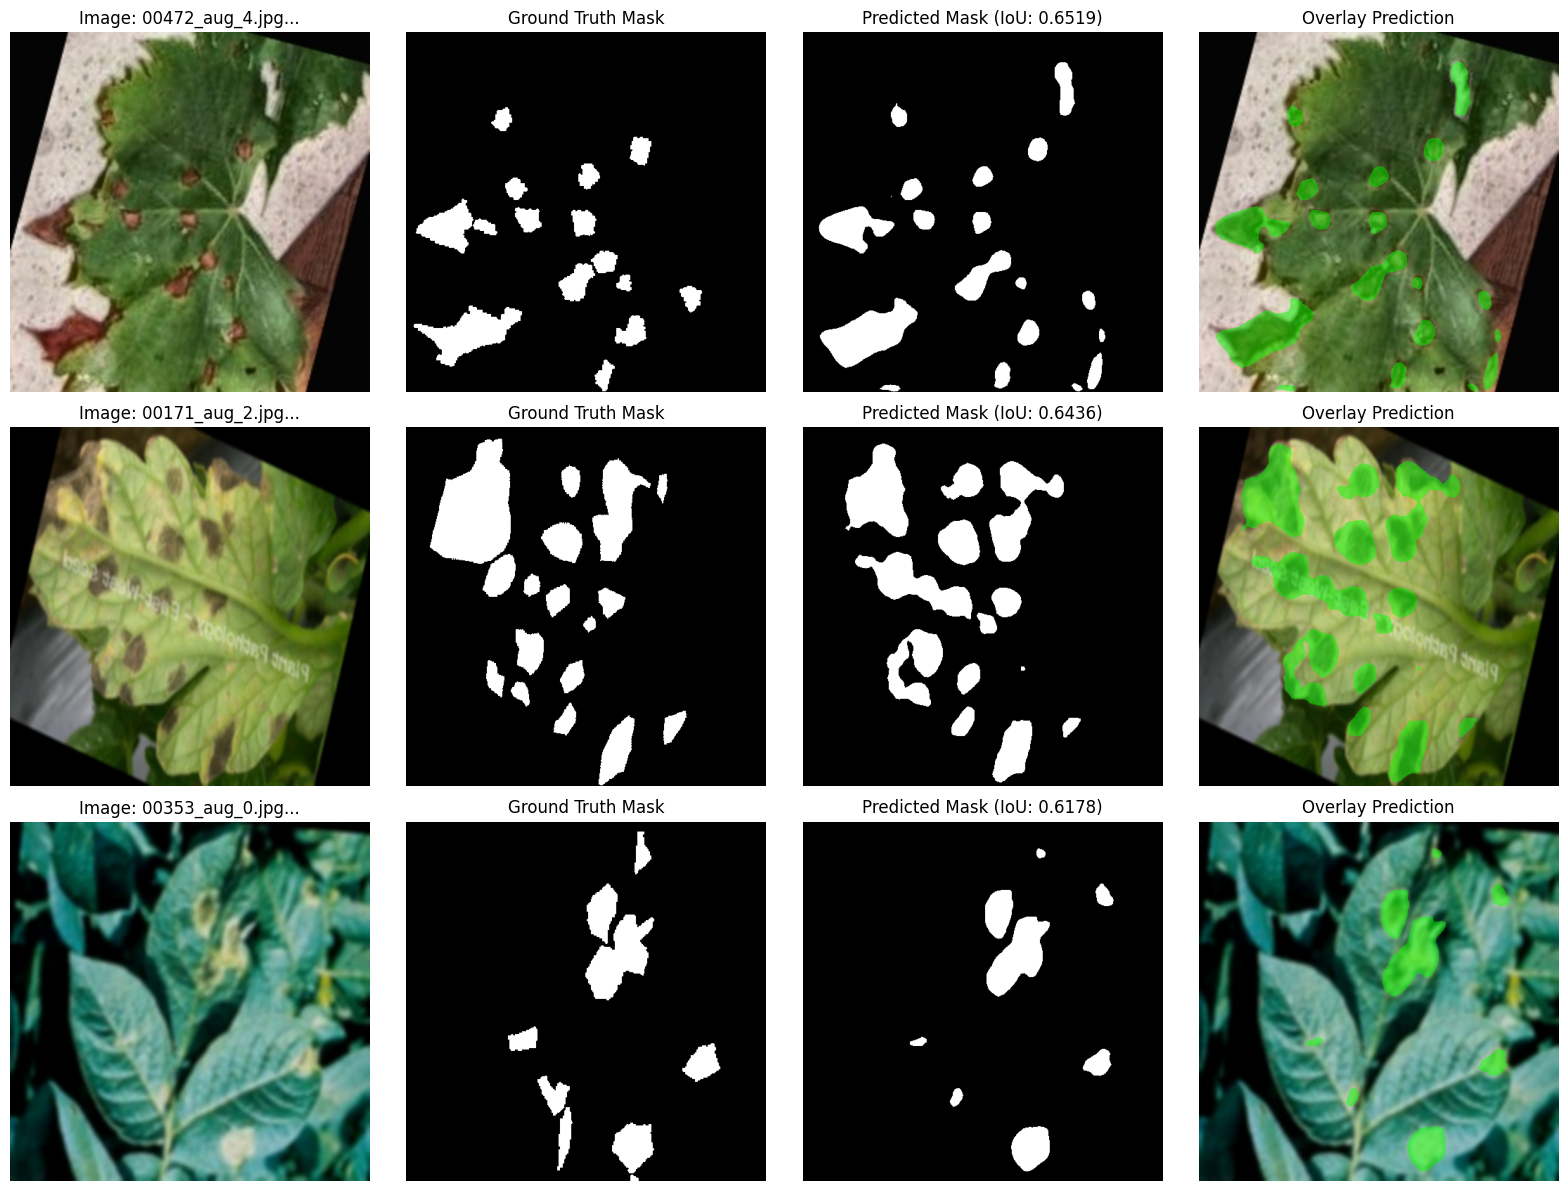

In [10]:
import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.DeepLabV3Plus(encoder_name= "resnet50", encoder_weights= None, in_channels= 3, classes= 1)

weights_path = "diseases_leaf_segmentation.pth"
if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"Successfully loaded trained weights from: {weights_path}")
else:
    raise FileNotFoundError(f"Could not find {weights_path}. Did the training loop save it?")

model = model.to(device)
model.eval()

sample_imgs = random.sample(val_imgs, min(3, len(val_imgs)))

fig, axes = plt.subplots(len(sample_imgs), 4, figsize=(16, 4 * len(sample_imgs)))
if len(sample_imgs) == 1:
    axes = np.expand_dims(axes, axis=0)

print("\nRunning inference validation on random samples...")

for idx, image_name in enumerate(sample_imgs):
    image_path = os.path.join("data/aug_data/images", image_name)

    base_name = image_name.split("_aug_")[0]
    base_name = os.path.splitext(base_name)[0]
    mask_name = f"{base_name}_aug_{image_name.split('_aug_')[1].split('.')[0]}.png" if "_aug_" in image_name else f"{base_name}.png"
    mask_path = os.path.join("data/aug_data/masks", mask_name)

    orig_image = cv2.imread(image_path)
    orig_image = cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB)

    resized_image = cv2.resize(orig_image, (512, 512))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    normalized_image = (resized_image / 255.0 - mean) / std

    input_tensor = torch.tensor(normalized_image, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (512, 512))
    gt_mask = (gt_mask > 0).astype(np.float32)

    with torch.no_grad():
        pred_logits = model(input_tensor)
        pred_probs = torch.sigmoid(pred_logits).squeeze().cpu().numpy()
        pred_mask = (pred_probs > 0.5).astype(np.float32)

    intersection = np.sum(pred_mask * gt_mask)
    union = np.sum(pred_mask) + np.sum(gt_mask) - intersection
    sample_iou = (intersection + 1e-6) / (union + 1e-6)

    overlay = resized_image.copy()
    overlay[pred_mask == 1] = overlay[pred_mask == 1] * 0.5 + np.array([0, 255, 0]) * 0.5

    axes[idx, 0].imshow(resized_image)
    axes[idx, 0].set_title(f"Image: {image_name[:15]}...")
    axes[idx, 0].axis("off")

    axes[idx, 1].imshow(gt_mask, cmap="gray")
    axes[idx, 1].set_title("Ground Truth Mask")
    axes[idx, 1].axis("off")

    axes[idx, 2].imshow(pred_mask, cmap="gray")
    axes[idx, 2].set_title(f"Predicted Mask (IoU: {sample_iou:.4f})")
    axes[idx, 2].axis("off")

    axes[idx, 3].imshow(overlay)
    axes[idx, 3].set_title("Overlay Prediction")
    axes[idx, 3].axis("off")

plt.tight_layout()
plt.show()